# Regresión Logística

## Descripción del modelo:

La regresión logística es una **técnica estadística de clasificación** que modela la **probabilidad de que Y** pertenezca a una clase particular.

Por ejemplo: P(aprobar/x=horas estudiando para el examen)

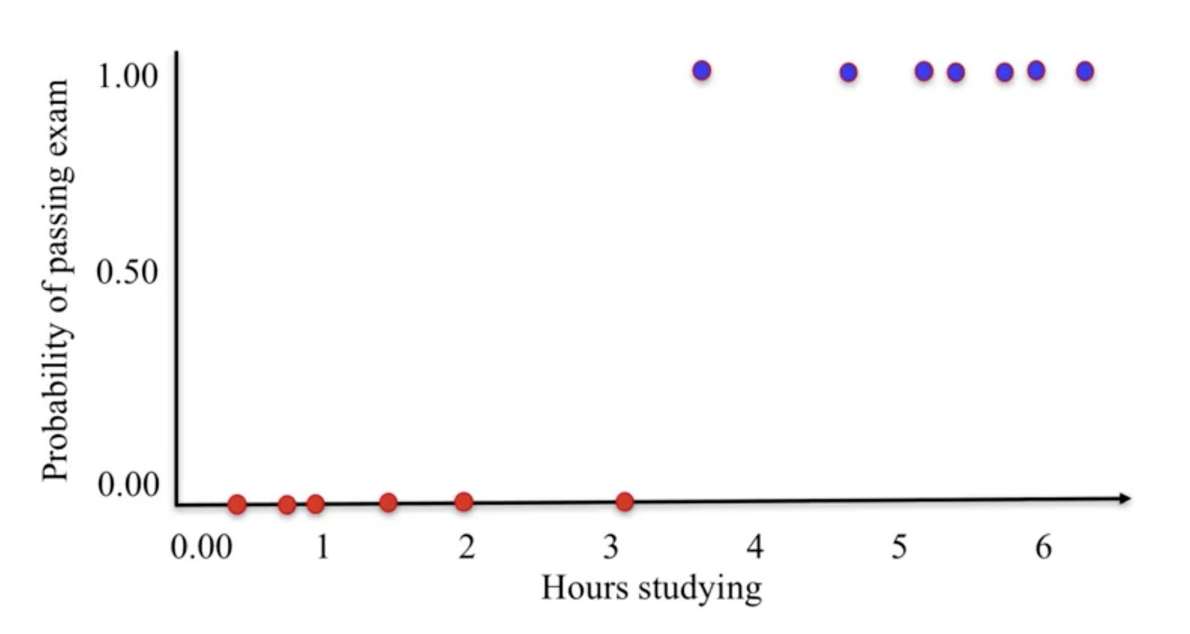

¿Podría estimarse la probabilidad utilizando una regresión lineal?

$$
p(y=1\mid x) = \beta_0 + \beta_1 x
$$

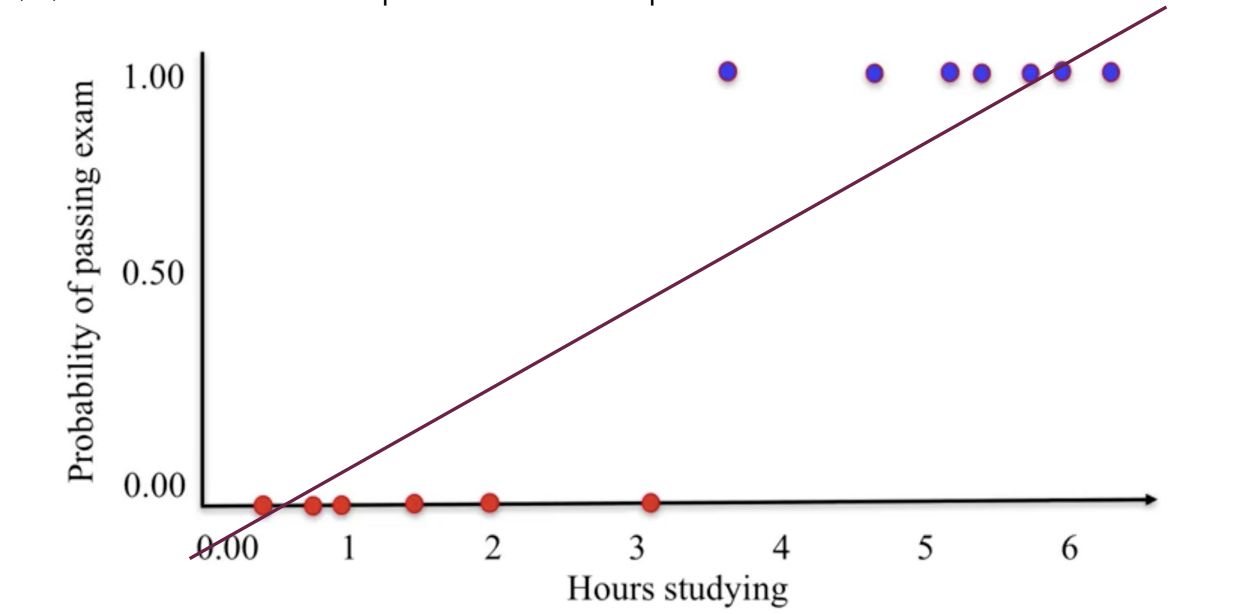

Podría hacerse, pero no es conveniente ya que la probabilidad resultante no va a ser interpretable

*   Podría arrojar valores por fuera del rango válido para una probabilidad [0, 1].
*   Tampoco serviría en problemas multiclase ya que interpretaría las clases como valores numéricos y que siguen cierto orden (ej: clases 1, 2 y 3)
*   Tampoco se cumple el supuesto de normalidad de los errores

Necesitamos una función con esta forma:

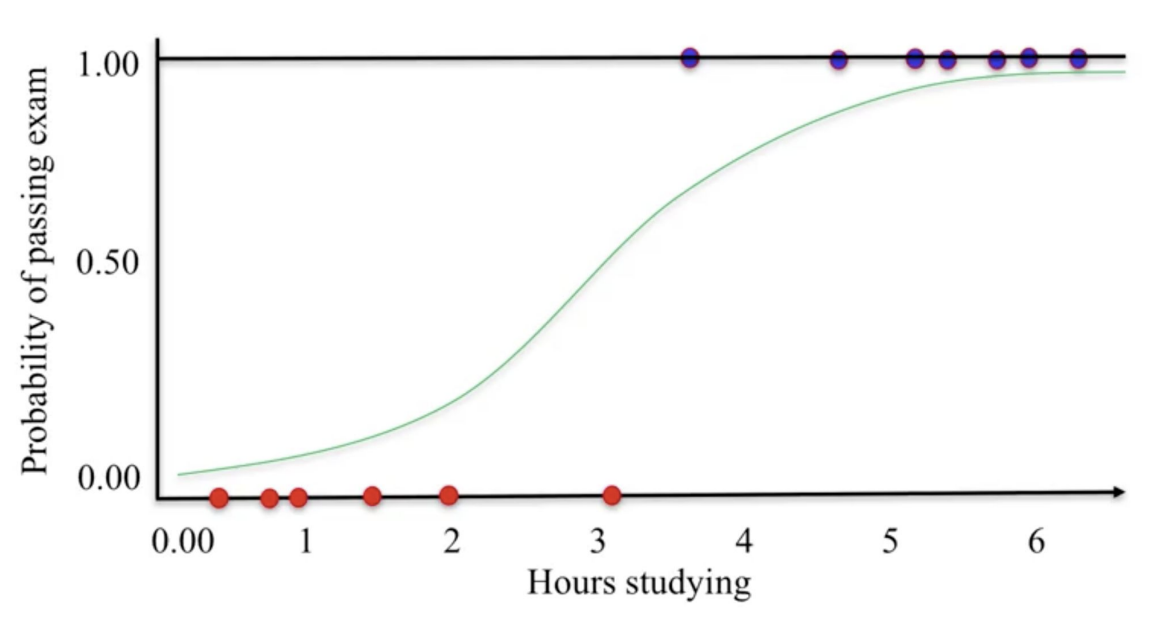

La función logística (sigmoidea) es una función con forma de S que transforma cualquier entrada de valor real en un número entre 0 y 1. Tiene esta forma:

$$
p(X) = \frac{e^{\beta_0 + \beta_1 X}}{1 + e^{\beta_0 + \beta_1 X}}
$$


Manipulando esa expresión obtenemos:

$$
\frac{p(X)}{1 - p(X)} = e^{\beta_0 + \beta_1 X}
$$

El termino $ \frac{p(X)}{1 - p(X)} $ toma valores entre 0 e infinito y se lo conoce como odds (o chances). Y relaciona la probabilidad de ocurrencia del evento y la no ocurrencia del mismo. Por ejemplo, con p(x)= 0.8 el odds es 0.8/0.2 = 4 significa que es 4 veces más probable la ocurrencia que la no ocurriencia del evento

Aplicando el logaritmo natural de ambos lados obtenemos:

$$
\log\left(\frac{p(X)}{1 - p(X)}\right) = \beta_0 + \beta_1 X
$$

Ahora sí puedo modelar el problema modelarlo como una función lineal

### Como estimo los coeficientes?
Los coeficientes $\beta_0$ y $\beta_1 $ son desconocidos y deben estimarse a partir de los datos de entrenamiento.

A diferencia de la regresión lineal en la que suele utilizarse mínimos cuadrados para definir los valores de los coeficientes, en la regresión logística suele utilizarse el método de máxima verosimilitud (maximum likelihood).

La idea es encontrar los valores de  $\beta_0$ y $\beta_1 $ que maximizan la probabilidad (verosimilitud) de observar los datos que realmente tenemos.


$$
L(\beta) = \prod_{i=1}^{n} \hat{p}_i^{y_i} (1 - \hat{p}_i)^{1 - y_i}
$$


Como multiplicar muchas probabilidades puede dar números muy pequeños, se suele maximizar el logaritmo de la verosimilitud (log-likelihood).

$$
\log L(\beta) = \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]
$$

Se utilizan algoritmos iterativos (ej. Newton-Raphson o descenso del gradiente) para encontrar los β que maximizan esta función

### Como hago la predicción?
Una vez estimados los coeficientes, podemos predecir la probabilidad p(X) para nuevas observaciones.

por ejemplo:

*   $\beta_0=-6$
*   $\beta_1=2$

¿cuál es la probabilidad de aprobar dado que estudió solo 1 hora?

$$
p(X=1) = \frac{e^{-6 + 2*1}}{1 + e^{-6 + 2*1}} = 0.018
$$

y alguien que estudió 4 horas?

$$
p(X=4) = \frac{e^{-6 + 2*4}}{1 + e^{-6 + 2*4}} = 0.88
$$

Para convertir estas probabilidades en una clasificación binaria (0 o 1), se establece un umbral de decisión (threshold). Comúnmente, se usa 0.5 (pero se puede ajustar según el problema):

Si p(X)>0.5 -> Clase 1

Si p(X)≤0.5 -> Clase 0

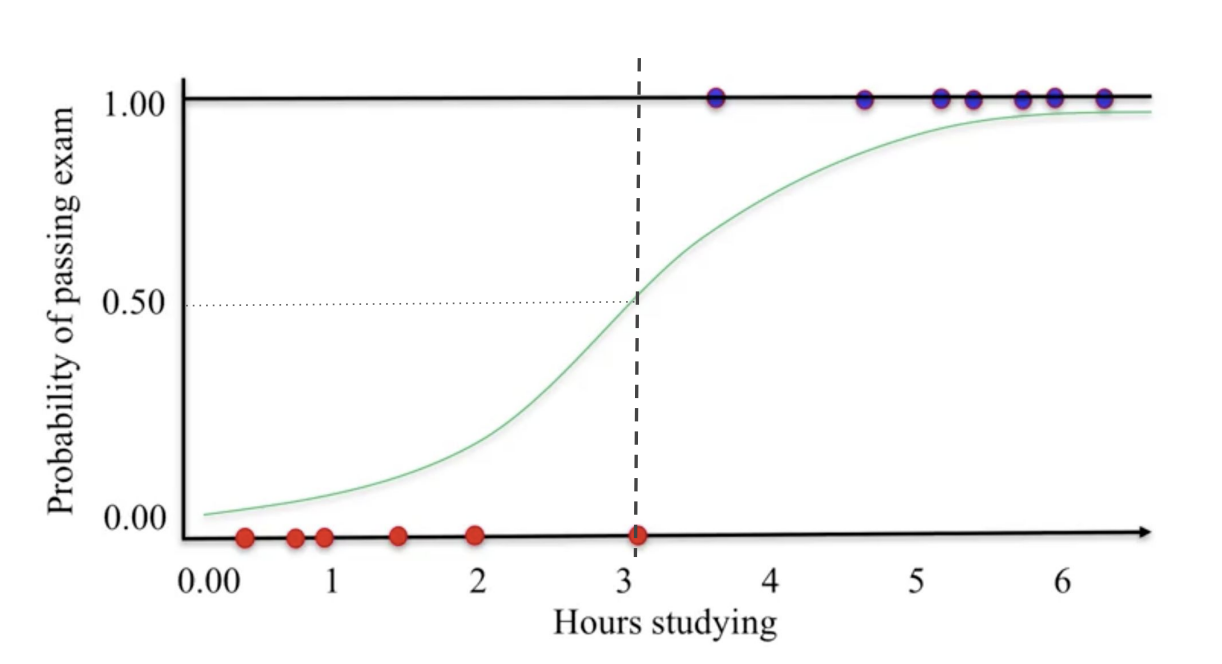

## Extensión a regresión logística multiple

$$
p(y = 1 \mid \mathbf{x}) = \frac{e^{\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k}}{1 + e^{\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_k x_k}}
$$

## Interpretación de coeficientes

En la regresión logística, cada coeficiente $\beta_j$ representa el cambio en el logaritmo de los *odds* asociado a un aumento de una unidad en la variable $x_j$, manteniendo constantes las demás variables. Es decir, $e^{\beta_j}$ indica cuánto se multiplican los *odds* ante una unidad adicional de $x_j$.

Sin embargo, a diferencia de la regresión lineal, este cambio **no implica una variación constante en la probabilidad** $p(X)$, ya que la relación entre las variables predictoras y la probabilidad es no lineal. El efecto de una unidad adicional en $x_j$ sobre $p(X)$ **depende del valor actual de las variables**.

Aun así, el **signo del coeficiente sí informa la dirección del efecto**: si $\beta_j > 0$, un aumento en $x_j$ incrementa la probabilidad del evento; si $\beta_j < 0$, la reduce.

## Ejemplo con el dataset de titanic

Importo las librerías necesarias:

In [13]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report
import statsmodels.api as sm # Opcional, para una visión más estadística similar a R

Levanto el dataset de titanic

In [14]:
# Configuración de visualizaciones (opcional)
#plt.style.use('seaborn-v0_8-whitegrid') # o cualquier otro estilo
#sns.set_palette("husl")

# Cargar el dataset del Titanic
# Este dataset está comúnmente disponible en la librería seaborn
df = sns.load_dataset('titanic')

Este dataset contiene información sobre los pasajeros del famoso transatlántico Titanic, que se hundió en 1912. El objetivo común de análisis con estos datos es predecir la supervivencia de los pasajeros a partir de características personales y del viaje.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


El dataset incluye un total de **891 pasajeros** y **15 variables**, entre demográficas, socioeconómicas y logísticas.

### 📋 Descripción de las variables

| Columna        | Tipo         | Descripción breve |
|----------------|--------------|--------------------|
| `survived`     | `int64`      | Indicador de supervivencia: `1` = sí, `0` = no |
| `pclass`       | `int64`      | Clase del boleto: `1` = primera, `2` = segunda, `3` = tercera |
| `sex`          | `object`     | Sexo del pasajero: `male` o `female` |
| `age`          | `float64`    | Edad del pasajero (en años) |
| `sibsp`        | `int64`      | Nº de hermanos/as o cónyuge a bordo |
| `parch`        | `int64`      | Nº de padres o hijos a bordo |
| `fare`         | `float64`    | Tarifa pagada por el boleto |
| `embarked`     | `object`     | Puerto de embarque: `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton |
| `class`        | `category`   | Clase del pasajero como texto: `First`, `Second`, `Third` |
| `who`          | `object`     | Grupo demográfico simplificado: `man`, `woman`, `child` |
| `adult_male`   | `bool`       | ¿Es un hombre adulto? |
| `deck`         | `category`   | Cubierta del barco (A–G), con muchos valores faltantes |
| `embark_town`  | `object`     | Ciudad de embarque: `Cherbourg`, `Queenstown`, `Southampton` |
| `alive`        | `object`     | Supervivencia como texto: `yes` o `no` |
| `alone`        | `bool`       | ¿Viajaba solo/a? |

Observo algunos registros:

In [17]:
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
235,0,3,female,NaN,0,0,7.55,S,Third,woman,False,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True
673,1,2,male,31.0,0,0,13.00,S,Second,man,True,NaN,Southampton,yes,True
505,0,1,male,18.0,1,0,108.90,C,First,man,True,C,Cherbourg,no,False
668,0,3,male,43.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


Pequeño análisis exploratorio del dataset:

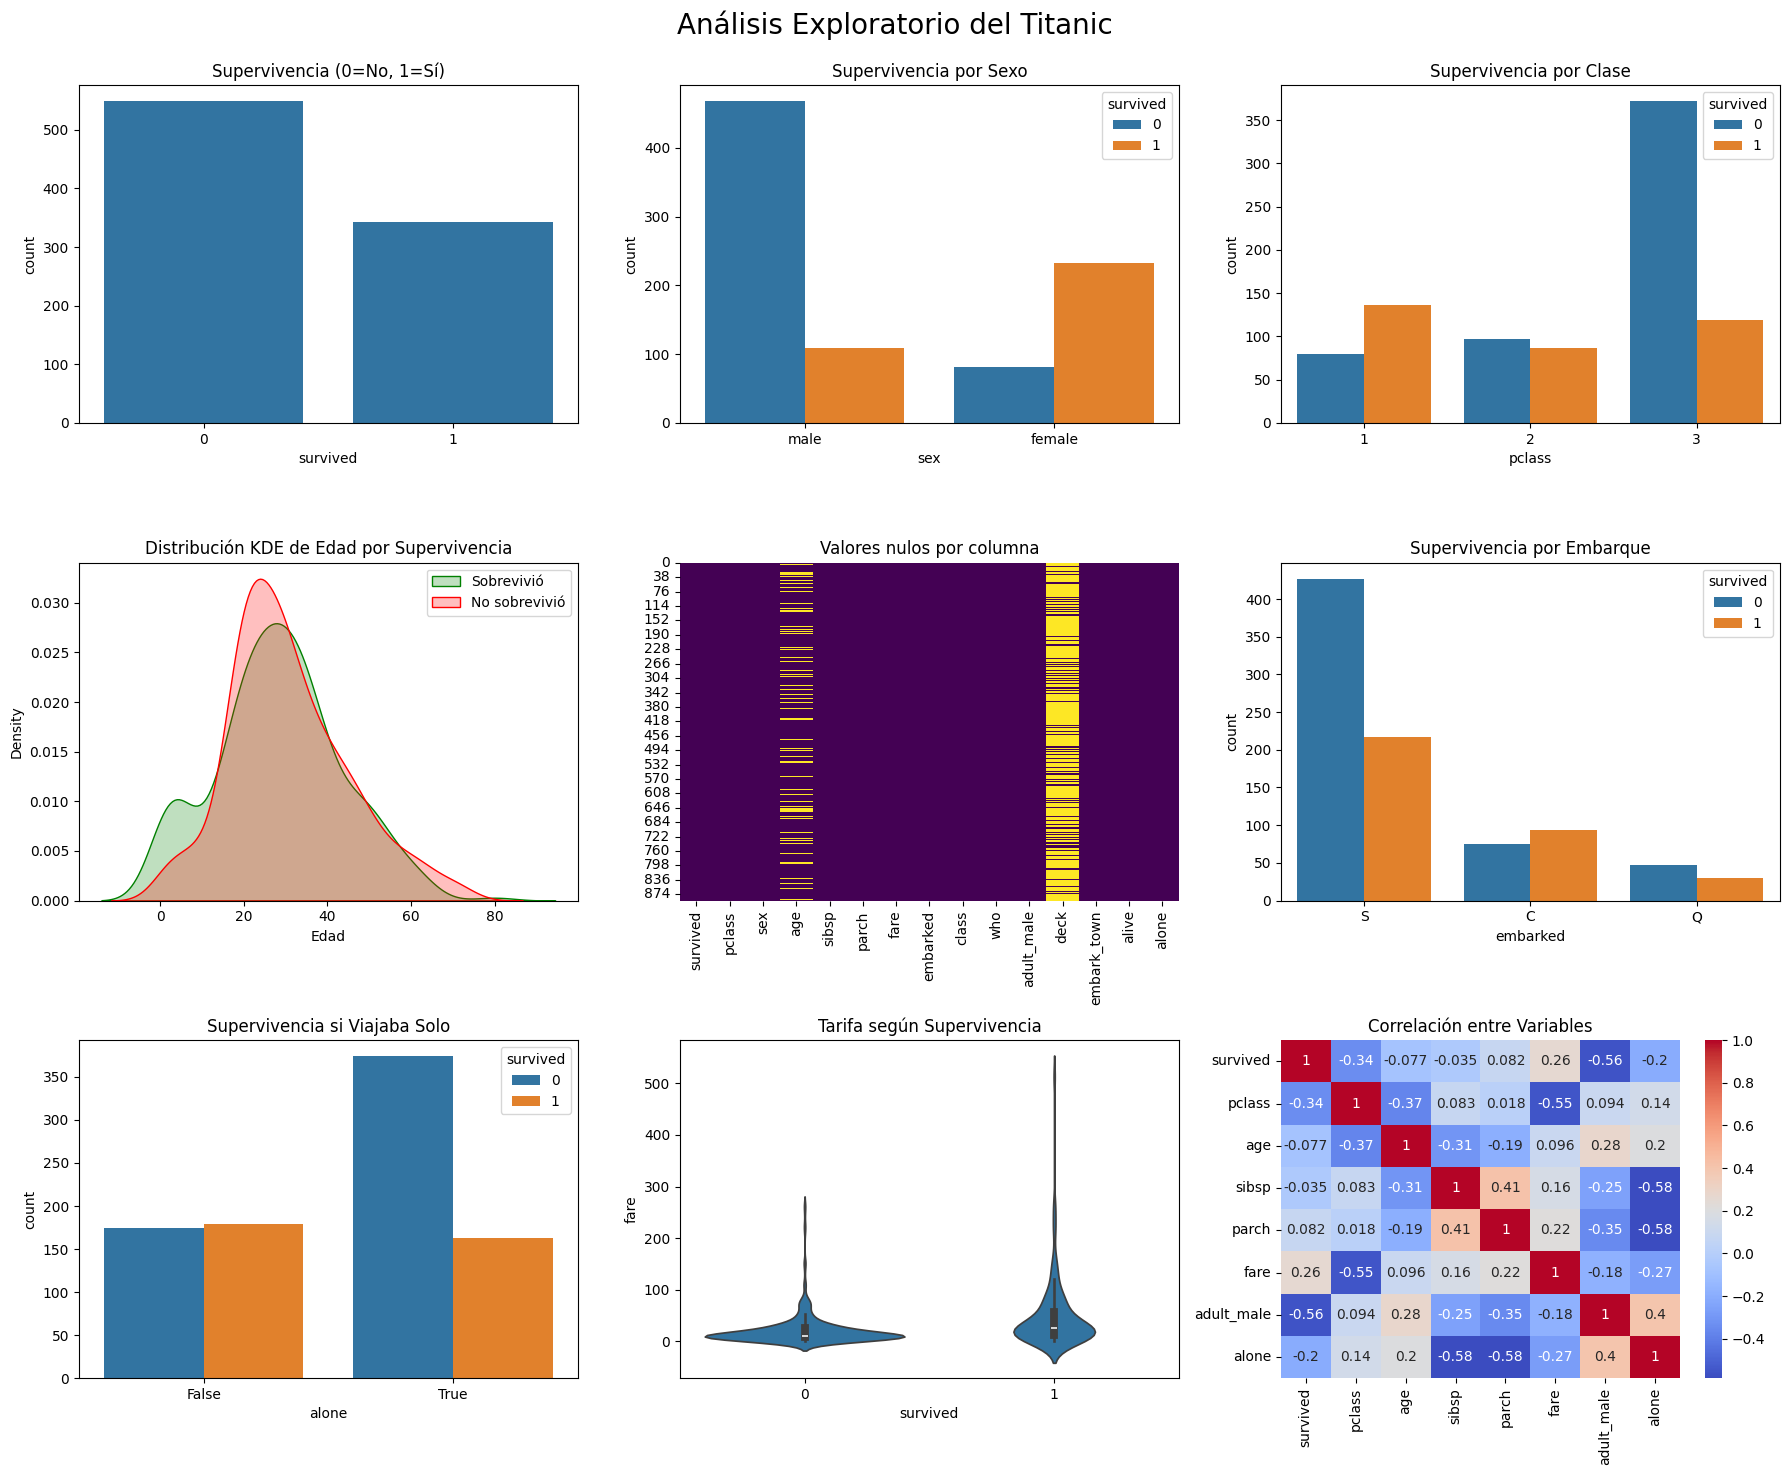

In [18]:
# Inicializar figura
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Análisis Exploratorio del Titanic', fontsize=20)

# 1. Supervivencia general
sns.countplot(x='survived', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Supervivencia (0=No, 1=Sí)')

# 2. Supervivencia por sexo
sns.countplot(x='sex', hue='survived', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Supervivencia por Sexo')

# 3. Supervivencia por clase
sns.countplot(x='pclass', hue='survived', data=df, ax=axes[0, 2])
axes[0, 2].set_title('Supervivencia por Clase')

# 4. Distribución de edad
sns.kdeplot(data=df[df['survived'] == 1], x='age', label='Sobrevivió', ax=axes[1, 0], fill=True, color='green')
sns.kdeplot(data=df[df['survived'] == 0], x='age', label='No sobrevivió', ax=axes[1, 0], fill=True, color='red')

axes[1, 0].set_title('Distribución KDE de Edad por Supervivencia')
axes[1, 0].set_xlabel('Edad')
axes[1, 0].legend()

# 5. Edad según supervivencia
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", ax=axes[1, 1])
axes[1, 1].set_title("Valores nulos por columna")

# 6. Supervivencia por puerto de embarque
sns.countplot(x='embarked', hue='survived', data=df, ax=axes[1, 2])
axes[1, 2].set_title('Supervivencia por Embarque')

# 7. Supervivencia según si viajaba solo
sns.countplot(x='alone', hue='survived', data=df, ax=axes[2, 0])
axes[2, 0].set_title('Supervivencia si Viajaba Solo')

# 8. Fare vs Survived (distribución tarifas)
sns.violinplot(x='survived', y='fare', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Tarifa según Supervivencia')

# 9. Correlaciones numéricas
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", ax=axes[2, 2])
axes[2, 2].set_title('Correlación entre Variables')

# Ajustar diseño
plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

Realizo preprocesamiento:

In [19]:
# Me quedo con un subset de variables
df = df[['survived', 'sex', 'age', 'fare', 'pclass', 'alone', 'embarked']]

# Completo valores nulos:
df['age'].fillna(df['age'].median(), inplace=True) # 'age': Imputar con la mediana
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True) # 'embarked': Imputar con el modo (valor más frecuente)

# Genero dummies para las variables categóricas:
df = pd.get_dummies(df, columns=['sex', 'embarked', 'pclass', 'alone'], drop_first=True)

/tmp/ipython-input-1427448456.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True) # 'age': Imputar con la mediana
/tmp/ipython-input-1427448456.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [20]:
df.sample()

,survived,age,fare,sex_male,embarked_Q,embarked_S,pclass_2,pclass_3,alone_True
872,0,33.0,5.0,True,False,True,False,False,True


Divido mi dataset entre train y test:

In [21]:
X = df.drop(['survived'], axis=1)
y = df['survived']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Regresión logística con `scikit-learn`

In [23]:
# Entrenamiento
model = LogisticRegression(max_iter=1000, penalty=None)
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)

print('Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

print('\nAccuracy:')
print(accuracy_score(y_test, y_pred))

Matriz de confusión:
[[134  31]
 [ 31  72]]

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       165
           1       0.70      0.70      0.70       103

    accuracy                           0.77       268
   macro avg       0.76      0.76      0.76       268
weighted avg       0.77      0.77      0.77       268


Accuracy:
0.7686567164179104


In [29]:
model.predict_proba(X_test)

array([[0.79727149, 0.20272851],
       [0.8907991 , 0.1092009 ],
       [0.85140625, 0.14859375],
       [0.91726662, 0.08273338],
       [0.9565792 , 0.0434208 ],
       [0.85306467, 0.14693533],
       [0.76654485, 0.23345515],
       [0.11573621, 0.88426379],
       [0.92547335, 0.07452665],
       [0.14248794, 0.85751206],
       [0.29670439, 0.70329561],
       [0.04636145, 0.95363855],
       [0.47902908, 0.52097092],
       [0.80446322, 0.19553678],
       [0.61594788, 0.38405212],
       [0.35628501, 0.64371499],
       [0.85140625, 0.14859375],
       [0.44618718, 0.55381282],
       [0.18685917, 0.81314083],
       [0.52871835, 0.47128165],
       [0.95364648, 0.04635352],
       [0.93740463, 0.06259537],
       [0.44915831, 0.55084169],
       [0.91718326, 0.08281674],
       [0.35909869, 0.64090131],
       [0.88380602, 0.11619398],
       [0.0474095 , 0.9525905 ],
       [0.59449704, 0.40550296],
       [0.81801818, 0.18198182],
       [0.7201107 , 0.2798893 ],
       [0.

In [24]:
print("\nIntercepto (beta_0):", model.intercept_)

coefficients = pd.DataFrame({'feature': X_train.columns, 'coefficient': model.coef_[0]})
print("\nCoeficientes del modelo:")
print(coefficients.sort_values(by='coefficient', ascending=False))


Intercepto (beta_0): [3.84660005]

Coeficientes del modelo:
      feature  coefficient
3  embarked_Q     0.291302
7  alone_True     0.091668
1        fare     0.001192
0         age    -0.038218
4  embarked_S    -0.406094
5    pclass_2    -1.042247
6    pclass_3    -2.305653
2    sex_male    -2.608714


Valores positivos, aumentan la probabilidad de supervivencia, valores negativos la reducen.

Por ejemplo:

##### 🔹 `sex_male`
Ser **hombre** reduce fuertemente las probabilidades de sobrevivir.  
El coeficiente es **-2.61**, por lo que los *odds* relativos se calculan como:

$ e^{-2.61} = 0.07 $


Esto significa que los *odds* (chances relativas) de que un hombre sobreviva son aproximadamente **0.07 veces** los de una mujer —es decir, **93% menores**— manteniendo el resto de las variables constantes.

---

##### 🔹 `embarked_Q`
Haber embarcado en el puerto de **Queenstown** aumenta moderadamente las probabilidades de sobrevivir en comparación con el puerto de referencia (probablemente **Cherbourg** o **Southampton**).  
El coeficiente es **0.29**, por lo que los *odds* relativos se calculan como:

$
e^{0.29} = 1.34
$

Esto significa que los *odds* de sobrevivir son aproximadamente **1.34 veces mayores** —un **34% de aumento**— respecto al puerto base.



### Regresión logística con `statsmodel`

In [25]:
X_train_stats = sm.add_constant(X_train.astype(float))
logit = sm.Logit(y_train, X_train_stats)

result = logit.fit()
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.442073
         Iterations 6
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: survived         Pseudo R-squared: 0.336     
Date:               2025-10-15 00:33 AIC:              568.8229  
No. Observations:   623              BIC:              608.7338  
Df Model:           8                Log-Likelihood:   -275.41   
Df Residuals:       614              LL-Null:          -414.80   
Converged:          1.0000           LLR p-value:      1.3422e-55
No. Iterations:     6.0000           Scale:            1.0000    
------------------------------------------------------------------
              Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
------------------------------------------------------------------
const         3.8426    0.5530    6.9485  0.0000   2.7587   4.9264
age          -0.0382    0.0091   -4.1936  0.0000  -0.0560  -0.

Cada coeficiente estimado en una regresión logística se somete a un test de hipótesis para evaluar si su valor es significativamente distinto de cero. La hipótesis nula ($ H_0 $) plantea que el coeficiente es cero, es decir, que esa variable no tiene efecto sobre la probabilidad del evento. El p-value indica la probabilidad de obtener una estimación tan extrema como la observada si ($ H_0 $) fuera cierta.
Un p-value bajo (por ejemplo, menor a 0.05) sugiere que hay evidencia estadística suficiente para rechazar la hipótesis nula, lo que implica que esa variable contribuye de forma significativa al modelo.

In [26]:
X_test_stats = sm.add_constant(X_test)

In [27]:
y_pred_stats = result.predict(X_test_stats.astype(float)) >= 0.5

confusion_matrix(y_test, y_pred_stats)

array([[134,  31],
       [ 31,  72]])

In [28]:
accuracy_score(y_test, y_pred_stats)

0.7686567164179104

## Bibliografía

Capítulo 4.3 de "An Introduction to Statistical Learning" (ISLR) - Gareth James, Daniela Witten, Trevor Hastie, Robert Tibshirani.